In [1]:
# 기본 경로 설정
# ===============================================================
import os
import requests

PROJECT_NUM = "13"

ROOT_DIR = os.getcwd()


try:
    from google.colab import drive, userdata
    IS_COLAB_MODE = True
    print("코랩 모드")

except ModuleNotFoundError as e:
    IS_COLAB_MODE = False
    ROOT_DIR = os.path.abspath(os.path.join(ROOT_DIR, ".."))
    print(f"{e}: 로컬 모드")


DATA_DIR = os.path.join(ROOT_DIR, "data")
RAW_DIR = os.path.join(DATA_DIR, "raw")
os.makedirs(DATA_DIR, exist_ok=True)


# 환경변수 로드 설정
def get_secret(key_name: str):
    if IS_COLAB_MODE:
        return userdata.get(key_name)
    else:
        from dotenv import load_dotenv
        load_dotenv(dotenv_path=os.path.join(ROOT_DIR, ".env"))
        return os.getenv(key_name)


if IS_COLAB_MODE:
    import subprocess

    drive.mount('/content/drive')

    # 압축 파일 확보
    if "raw.tar.gz" not in os.listdir():

        headers = {
            "Authorization": f"token {get_secret('GITHUB_PAT')}",
            "Accept": "application/vnd.github.v3+json"
        }

        release_url = f"https://api.github.com/repos/wonbywondev/ML-DL-data/releases/tags/data-v{PROJECT_NUM}"

        response = requests.get(release_url, headers=headers)
        asset_id = response.json().get('assets', [])[0]["id"]

        download_url = f"https://api.github.com/repos/wonbywondev/ML-DL-data/releases/assets/{asset_id}"
        download_headers = headers.copy()
        download_headers["Accept"] = "application/octet-stream"

        with requests.get(download_url, headers=download_headers, stream=True) as r:
            r.raise_for_status()
            with open("raw.tar.gz", 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)

    print("· 압축 파일 있음")


    # 압축 해제 및 경로 처리
    if not os.path.exists(RAW_DIR):
        subprocess.run(["tar", "-xzvf", "raw.tar.gz", "-C", DATA_DIR], check=True)

    print("· 압축 해제 완료")
    print("· 환경 세팅 완료")


    DRIVE_DIR = os.path.join(ROOT_DIR, "drive", "MyDrive")
    SAVE_DIR = os.path.join(DRIVE_DIR, "runs", PROJECT_NUM)

    os.makedirs(SAVE_DIR, exist_ok=True)

코랩 모드
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
· 압축 파일 있음
· 압축 해제 완료
· 환경 세팅 완료


In [2]:
# 기타 환경 설정
import torch
import matplotlib.pyplot as plt
import gc


# 시각화 관련 설정
if not IS_COLAB_MODE:
    import matplotlib.font_manager as fm
    try:
        plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
    except:
        try:
            plt.rcParams['font.family'] = 'NanumGothic'
        except:
            plt.rcParams['font.family'] = 'AppleGothic'

    plt.rcParams['axes.unicode_minus'] = False
    fm._load_fontmanager(try_read_cache=False)


# 디바이스 설정
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps") # 맥 GPU
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda") # 윈도우 GPU
else:
    DEVICE = torch.device("cpu") # CPU


# 캐시 지우기 함수 생성
def clean_cache():
    gc.collect()
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()


# MallocStackLogging 에러 출력 방지
os.environ.pop("MallocStackLogging", None)
os.environ.pop("MallocStackLoggingNoCompact", None)
os.environ.pop("DYLD_INSERT_LIBRARIES", None)

선정 모델: https://huggingface.co/tabularisai/multilingual-sentiment-analysis

In [ ]:
# 모델 선정

import torch.optim as optim
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "tabularisai/multilingual-sentiment-analysis"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

optimizer = optim.AdamW(model.parameters(), lr=2e-5)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at tabularisai/multilingual-sentiment-analysis and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([5]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([5, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a 

In [ ]:
# 데이터 샘플 출력

import random
import json
from pathlib import Path

RAW_JSON_PATH_LIST = [
    str(path) for path in Path(RAW_DIR).rglob("*.json")
    if not path.name.startswith(".")
]

rand_idx = random.randint(1, len(RAW_JSON_PATH_LIST))
rand_path = RAW_JSON_PATH_LIST[rand_idx - 1]

with open(rand_path, "r", encoding="utf-8") as f:
    sample = json.load(f)

rand_idx = random.randint(1, len(sample))
sample[rand_idx - 1]

{'Index': '1023702',
 'RawText': '오늘 소개 해드릴 제품은 바로 이 제품입니다!! 이 제품 역시 제가 좋아하는 제품 중에 하나라 저만 알고 싶었던 제품인데... 알려 드리려고 하니까 살짝 서운하네요 ㅎㅎ 농담이구용 ㅋㅋㅋㅋㅋ 제가 써보고 좋았던 점 나빴던 점 다 알려 드릴게요~ 잘 들어주세요!  특이하게 단점부터 시작할게요! 이 제품의 단점은 머리 세팅이 잘 되는 것 같지는 않아요...ㅠㅠ 이 점 때문에 초반에는 사용을 할까 말까 고민을 많이 했습니다! 그리고 저는 살짝 끈적거렸던 것 같습니다.. 이 두 가지가 단점이라고 할 수 있고 장점은 가격이 저렴하고 용량이 엄청 커요!! 그리고 머릿결은 진짜 좋아집니다! 그래서 저는 좋았다고 한 겁니다!!  장단점이 극명한 제품이라 누구는 좋고 누구는 안 좋을 수 있어요~ 저는 좋아서 사용하고 있습니다 ^^',
 'Source': 'SNS',
 'Domain': '화장품',
 'MainCategory': '헤어/바디케어',
 'ProductName': 'OO 과** 컨퓸 헤어 밀키 로션 600ml 1개',
 'Syllable': '404',
 'Word': '104',
 'GeneralPolarity': '1',
 'Aspects': [{'Aspect': '세팅력/고정력',
   'SentimentText': '이 제품의 단점은 머리 세팅이 잘 되는 것 같지는 않아요...ㅠㅠ ',
   'SentimentWord': '10',
   'SentimentPolarity': '-1'},
  {'Aspect': '스타일링효과',
   'SentimentText': ' 살짝 끈적거렸던 것 같습니다.. ',
   'SentimentWord': '4',
   'SentimentPolarity': '-1'},
  {'Aspect': '가격',
   'SentimentText': '가격이 저렴하고',
   'SentimentWord': '2',
   'SentimentPolarity': '1'},
  {'As

- RawText가 문장 단위로 구성되어 있지 않고, 문장 단위를 구별할 수 있는 문장 부호도 불규칙하다.

- 따라서 Aspect와 SentimentText, SentimentPolarity가 데이터의 관점에서는 더욱 적합해보인다.

# 실험 설계

1. RawText를 이용하여 Full Fine-tuning과 QLoRA의 성능을 비교한다.

2. SentimentText와 SentimentPolarity로 QLoRA의 성능을 확인한다.(상세 모델)

    - Aspect 기반으로 stratify 진행

3. 최종 성능을 비교한다.

## 실험 결과(실험 코드 아래 참조)

#### 1 에포크 당 평균 소요 시간

- 풀 파인 튜닝: 100분

- QLoRA: 56분

- QLoRA(상세 정보): 57분

#### 결론(그래프 아래 참조)

- 풀 파인튜닝 모델이 F1 스코어 등의 관점에서 가장 우수한 성능을 보였다.

  - 단, QLoRA의 약 2배 가량의 학습 시간이 소요되었으며 이에 따라 완벽한 모델로 여길 수는 없다.

- QLoRA 모델들의 경우 성능이 비교적 떨어지는 Neutral 데이터들을 중심으로 추가 학습을 진행할 수 있을 것이다.

- 예를 들어, 지속적으로 개량을 요하는 서비스에서는 QLoRA로 학습 인터벌을 더 짧게 설정하고, 그렇지 않은 서비스에서는 풀 파인튜닝 모델을 차용하는 등 운용 전략을 상황에 따라 다르게 설정할 수 있을 것으로 보인다.

- 코랩의 런타임 제한 문제로 추가적인 학습을 더욱 진행하지 못한 점이 아쉬움으로 남는다.

In [ ]:
f_model = prepare_best_model(fft_config)
q_model = prepare_best_model(qlora_config)
p_model = prepare_best_model(peft_aspect_config)

f_label_list, f_pred_list = evaluate(f_model)
q_label_list, q_pred_list = evaluate(q_model)
p_label_list, p_pred_list = evaluate(p_model)

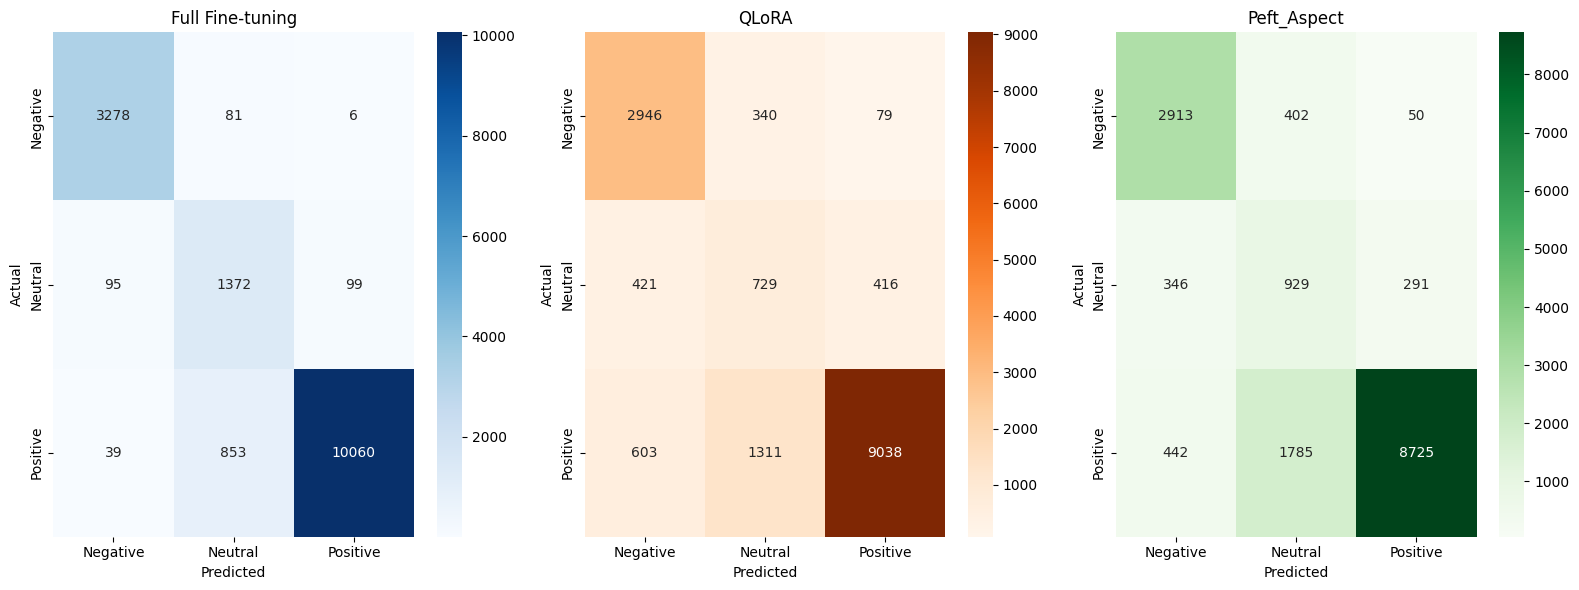


F1-score


,Full Fine,QLoRA,Peft_Aspect
Negative,0.9674,0.8033,0.8245
Neutral,0.7087,0.3695,0.3968
Positive,0.9528,0.8824,0.8717
accuracy,0.9261,0.8004,0.7912
macro avg,0.8763,0.6851,0.6977
weighted avg,0.9318,0.8151,0.8149



Full Fine


,precision,recall,f1-score,support
Negative,0.9607,0.9741,0.9674,3365.0000
Neutral,0.5950,0.8761,0.7087,1566.0000
Positive,0.9897,0.9186,0.9528,10952.0000
accuracy,0.9261,0.9261,0.9261,0.9261
macro avg,0.8485,0.9229,0.8763,15883.0000
weighted avg,0.9446,0.9261,0.9318,15883.0000



QLoRA


,precision,recall,f1-score,support
Negative,0.7421,0.8755,0.8033,3365.0000
Neutral,0.3063,0.4655,0.3695,1566.0000
Positive,0.9481,0.8252,0.8824,10952.0000
accuracy,0.8004,0.8004,0.8004,0.8004
macro avg,0.6655,0.7221,0.6851,15883.0000
weighted avg,0.8412,0.8004,0.8151,15883.0000



Peft_Aspect


,precision,recall,f1-score,support
Negative,0.7871,0.8657,0.8245,3365.0000
Neutral,0.2981,0.5932,0.3968,1566.0000
Positive,0.9624,0.7967,0.8717,10952.0000
accuracy,0.7912,0.7912,0.7912,0.7912
macro avg,0.6825,0.7519,0.6977,15883.0000
weighted avg,0.8598,0.7912,0.8149,15883.0000


In [37]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

target_names = ["Negative", "Neutral", "Positive"]


f_cm = confusion_matrix(f_label_list, f_pred_list)
q_cm = confusion_matrix(q_label_list, q_pred_list)
p_cm = confusion_matrix(p_label_list, p_pred_list)



fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Full Fine-tuning 히트맵
sns.heatmap(f_cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title("Full Fine-tuning")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# QLoRA 히트맵
sns.heatmap(q_cm, annot=True, fmt="d", cmap="Oranges", ax=axes[1],
            xticklabels=target_names, yticklabels=target_names)
axes[1].set_title("QLoRA")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(p_cm, annot=True, fmt="d", cmap="Greens", ax=axes[2],
            xticklabels=target_names, yticklabels=target_names)
axes[2].set_title("Peft_Aspect")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()



f_result_df = pd.DataFrame(
    classification_report(
        f_label_list,
        f_pred_list,
        target_names=target_names,
        output_dict=True
    )
).transpose()

q_result_df = pd.DataFrame(
    classification_report(
        q_label_list,
        q_pred_list,
        target_names=target_names,
        output_dict=True
    )
).transpose()

p_result_df = pd.DataFrame(
    classification_report(
        p_label_list,
        p_pred_list,
        target_names=target_names,
        output_dict=True
    )
).transpose()


compare_df = pd.DataFrame({
    "Full Fine": f_result_df["f1-score"],
    "QLoRA": q_result_df["f1-score"],
    "Peft_Aspect": p_result_df["f1-score"],
})

print("\nF1-score")
display(compare_df.round(4))

print("\nFull Fine")
display(f_result_df.round(4))

print("\nQLoRA")
display(q_result_df.round(4))

print("\nPeft_Aspect")
display(p_result_df.round(4))

---

# 실험 진행

### RawText 전처리 및 데이터셋 생성

In [5]:
import pandas as pd

column_list = ["RawText", "Word", "GeneralPolarity"]
all_data = []

for path in RAW_JSON_PATH_LIST:
    with open(path, "r", encoding="utf-8") as f:
        dict_list = json.load(f)

        for item in dict_list:
            filtered_item = {key: item.get(key) for key in column_list}
            all_data.append(filtered_item)

filtered_df = pd.DataFrame(all_data, columns=column_list)

print(f"· 총 데이터: {len(filtered_df)}개")

· 총 데이터: 201616개


In [6]:
print("[결측치]")

for column in column_list:
    if sum(filtered_df[column].isna()) > 0:
        print(f"· 결측 항목: {column}")
        print(f"· {sum(filtered_df[column].isna())}개")
        print(f"· 예시: \n{filtered_df[filtered_df[column].isna()].head(5)}")

        filtered_df = filtered_df.dropna()
        print(f"\n· 제거 후 데이터: {len(filtered_df)}개")

filtered_df["GeneralPolarity"] = filtered_df["GeneralPolarity"].astype(int)

[결측치]
· 결측 항목: GeneralPolarity
· 17091개
· 예시: 
                                                RawText Word GeneralPolarity
722   기존OOO와 냄새가 달라요.얼굴이 따가워요 사용해서 반품도 안된데요.   제품들고 ...   20            None
773   OO쇼핑에서  매번 저렴하게 구매하는 OOO입니다. 유통기한이  짧을까봐 걱정했는데...   13            None
1062  어머니가  쓰시는거라서   요즘  핫하다는  OOO 열심히 사다 조공하고있어요%^^...   44            None
1099  OOO씨 광고 하기전부터 지인한테 선물받아 사용했는데 꾸준히 쓰고있어요! 엄마도 같...   26            None
2003  하고나면 화면처럼 단단하게 석고팩이 되지는 않고 수분팩의 에센스양이 다른 팩에비해 ...   19            None

· 제거 후 데이터: 184525개


In [7]:
print("[중복치]")

if sum(filtered_df["RawText"].duplicated()) > 0:
    print(filtered_df[filtered_df["RawText"].duplicated()].head(5))

else:
    print("· 중복치 없음")

[중복치]
· 중복치 없음


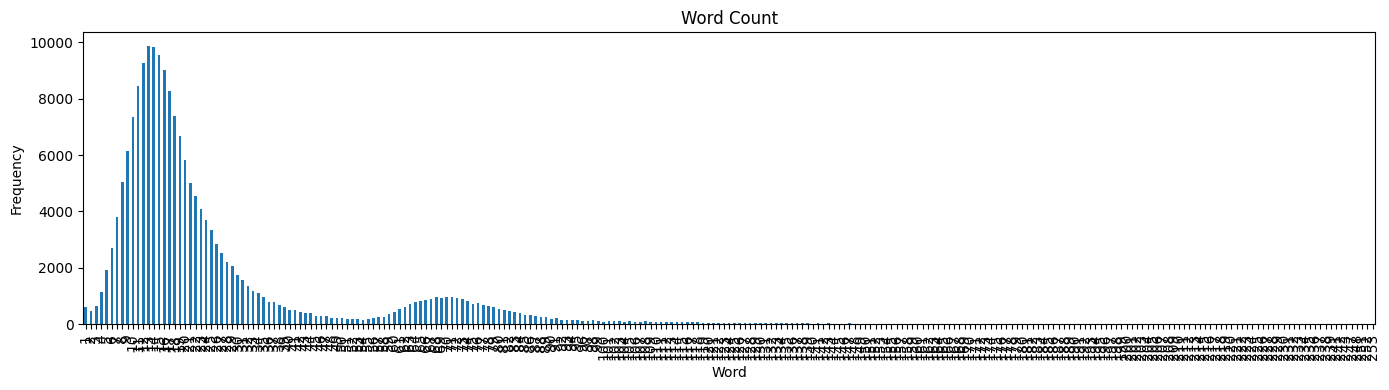

In [8]:
filtered_df["Word"] = filtered_df["Word"].astype(int)

data = filtered_df["Word"].value_counts().sort_index()

plt.figure(figsize=(14,4))
data.plot(kind="bar")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Word Count")
plt.tight_layout()
plt.show()

In [9]:
print("[극단치]")

filtered_df = filtered_df[filtered_df["Word"] <= 50]

print(f"· 제거 후 데이터: {len(filtered_df)}개")

[극단치]
· 제거 후 데이터: 158825개


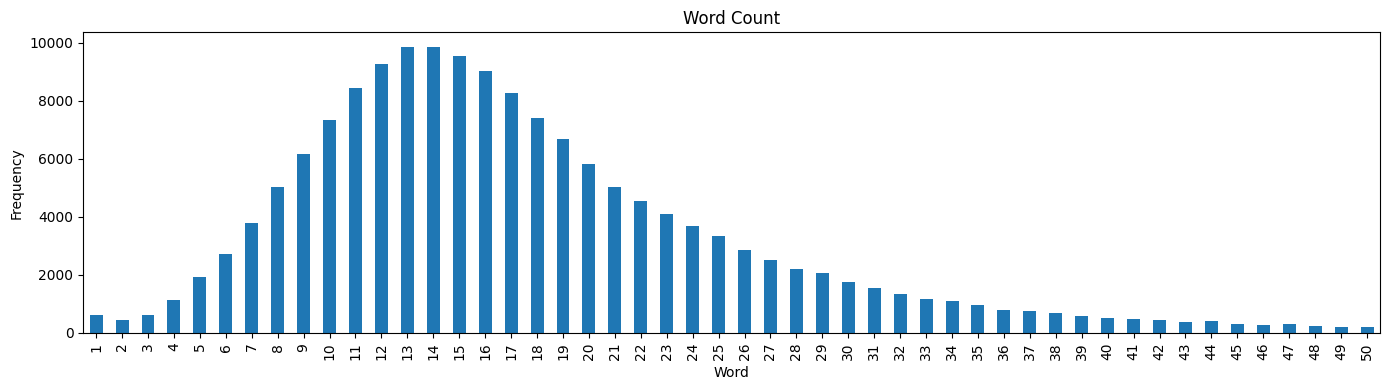

In [10]:
data = filtered_df["Word"].value_counts().sort_index()

plt.figure(figsize=(14,4))
data.plot(kind="bar")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Word Count")
plt.tight_layout()
plt.show()

filtered_df = filtered_df.drop("Word", axis=1)

In [11]:
filtered_df = filtered_df.reset_index().drop("index", axis=1)

filtered_df["GeneralPolarity"] += 1

filtered_df["GeneralPolarity"].value_counts()

,count
GeneralPolarity,
2,100348
1,33299
0,25178


---

In [12]:
RAW_TEXT_LIST = list(filtered_df["RawText"])
CLASS_LIST = list(filtered_df["GeneralPolarity"])

In [13]:
from torch.utils.data import Dataset

class RawTextDataset(Dataset):
    def __init__(self):
        self.X_list = RAW_TEXT_LIST
        self.y_list = CLASS_LIST

    def __len__(self):
        return len(self.X_list)

    def __getitem__(self, index):
        X = self.X_list[index]

        X = tokenizer(
            X,
            add_special_tokens=True,
            max_length=512,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        y = self.y_list[index]

        return {
            "input_ids": X["input_ids"].squeeze(0),
            "attention_mask": X["attention_mask"].squeeze(0),
            "labels": torch.tensor(y, dtype=torch.long)
        }


RAW_DATASET = RawTextDataset()

In [14]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader, WeightedRandomSampler

train_indices, tmp_indices = train_test_split(
    list(range(len(RAW_DATASET))),
    test_size=0.2,
    stratify=CLASS_LIST
)

val_indices, test_indices = train_test_split(
    list(range(len(tmp_indices))),
    test_size=0.5,
    stratify=[CLASS_LIST[idx] for idx in tmp_indices]
)

raw_train_subset = Subset(RAW_DATASET, train_indices)
raw_val_subset = Subset(RAW_DATASET, val_indices)
raw_test_subset = Subset(RAW_DATASET, test_indices)

print(f"[분할 결과]")
print(f"· 기존 학습 데이터: {len(RAW_DATASET)}개")
print(f"· 분할 후 학습 데이터: {len(train_indices)}개 ({len(train_indices) / len(RAW_DATASET) * 100:.2f}%)")
print(f"· 분할 후 검증 데이터: {len(val_indices)}개 ({len(val_indices) / len(RAW_DATASET) * 100:.2f}%)")
print(f"· 분할 후 테스트 데이터: {len(test_indices)}개 ({len(test_indices) / len(RAW_DATASET) * 100:.2f}%)")

[분할 결과]
· 기존 학습 데이터: 158825개
· 분할 후 학습 데이터: 127060개 (80.00%)
· 분할 후 검증 데이터: 15882개 (10.00%)
· 분할 후 테스트 데이터: 15883개 (10.00%)


In [15]:
# 샘플러 설정
labels = torch.tensor([CLASS_LIST[idx] for idx in train_indices])

class_counts = torch.bincount(labels)
class_weights = len(train_indices) / class_counts.float()
samples_weights = class_weights[labels]

raw_sampler = WeightedRandomSampler(
    weights=samples_weights,
    num_samples=len(samples_weights),
    replacement=True
)

print(f"[학습 데이터]")
print(f"· 부정 리뷰: {class_counts[0]}개 ({class_counts[0] / len(labels) * 100:.2f}%)")
print(f"· 중립 리뷰: {class_counts[1]}개 ({class_counts[1] / len(labels) * 100:.2f}%)")
print(f"· 긍정 리뷰: {class_counts[2]}개 ({class_counts[2] / len(labels) * 100:.2f}%)")

print(f"\n[샘플러 가중치]")
print(f"· 부정 클래스: {class_weights[0]:.4f}")
print(f"· 중립 클래스: {class_weights[1]:.4f}")
print(f"· 긍정 클래스: {class_weights[2]:.4f}")


# 채널별 데이터 로더 설정
RAW_TRAIN_LOADER = DataLoader(raw_train_subset, batch_size=32, sampler=raw_sampler, shuffle=False, num_workers=2)
RAW_VAL_LOADER = DataLoader(raw_val_subset, batch_size=32, shuffle=False, num_workers=2)
RAW_TEST_LOADER = DataLoader(raw_test_subset, batch_size=32, shuffle=False, num_workers=2)

[학습 데이터]
· 부정 리뷰: 20143개 (15.85%)
· 중립 리뷰: 26639개 (20.97%)
· 긍정 리뷰: 80278개 (63.18%)

[샘플러 가중치]
· 부정 클래스: 6.3079
· 중립 클래스: 4.7697
· 긍정 클래스: 1.5827


In [16]:
# 학습 유틸리티 설정

# wandb
if IS_COLAB_MODE:
    subprocess.run(["pip", "install", "wandb", "-qU"])

import wandb

wandb.login(key=get_secret("WANDB_API_KEY"))


# 텔레그램
def send_telegram_msg(message):
    token = get_secret("TELEGRAM_BOT_TOKEN")
    chat_id = get_secret("TELEGRAM_CHAT_ID")

    url = f'https://api.telegram.org/bot{token}/sendMessage'
    payload = {
        'chat_id': chat_id,
        'text': message
    }

    requests.post(url, json=payload)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: wsi0720 (wsi0720-sungkyunkwan-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [17]:
class RawTrainerConfig:
    def __init__(self, mode, patience=3):
        self.mode = mode
        self.save_dir = os.path.join(SAVE_DIR, self.mode)
        os.makedirs(self.save_dir, exist_ok=True)

        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.early_stop = False

        self.time_dict = dict()


    def step(self, epoch, train_loss, val_loss, model, epoch_time):

        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0

            model.save_pretrained(os.path.join(self.save_dir, "best_model"))

            torch.save({
                "epoch": epoch,
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss
            }, os.path.join(self.save_dir, "best_model", "training_state.pt"))

        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


        model.save_pretrained(os.path.join(self.save_dir, "last_model"))

        torch.save({
            "epoch": epoch,
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss
        }, os.path.join(self.save_dir, "last_model", "training_state.pt"))


        wandb.log({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "best_val_loss": self.best_loss
        })

        self.time_dict[epoch] = epoch_time

In [18]:
import time
from tqdm.auto import tqdm

def train_model(start_epoch: int, num_epochs: int, model, optimizer, config: RawTrainerConfig):
    start_time = time.perf_counter()

    for epoch in range(start_epoch, start_epoch + num_epochs):
        epoch += 1
        clean_cache()

        # 학습 모드
        model.train()
        total_train_loss = 0

        train_pbar = tqdm(RAW_TRAIN_LOADER, desc=f"Epoch {epoch} [Train]")

        for batch in train_pbar:
            save_step = False

            optimizer.zero_grad()

            batch = {key: value.to(DEVICE) for key, value in batch.items()}

            outputs = model(**batch)
            loss = outputs.loss

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

            train_pbar.set_postfix({"loss": f"{loss.item():.4f}"})

            if time.perf_counter() - start_time > 600:
                save_step = True


        average_train_loss = total_train_loss / len(RAW_TRAIN_LOADER)
        print(f"· Epoch {epoch} Train Loss: {average_train_loss:.4f}")


        # 평가 모드
        model.eval()
        total_val_loss = 0

        val_pbar = tqdm(RAW_VAL_LOADER, desc=f"Epoch {epoch} [Val]")

        with torch.no_grad():
            for batch in val_pbar:
                batch = {key: value.to(DEVICE) for key, value in batch.items()}
                outputs = model(**batch)
                total_val_loss += outputs.loss.item()

                val_pbar.set_postfix({"val_loss": f"{outputs.loss.item():.4f}"})

        average_val_loss = total_val_loss / len(RAW_VAL_LOADER)

        end_time = time.perf_counter()
        epoch_time = (end_time - start_time) / 60

        print(f"· Epoch {epoch} Val Loss: {average_val_loss:.4f} (소요 시간: {epoch_time:.1f}분)")

        config.step(epoch, average_train_loss, average_val_loss, model, epoch_time)


        if config.early_stop:
            send_telegram_msg(f"{config.mode} epoch {epoch} 학습 완료(얼리 스톱)")
            print("Early Stopped")
            break

        else:
            send_telegram_msg(
                f"""
                {config.mode} epoch {epoch} 학습 완료
                · Train Loss: {average_train_loss:.4f} | Val Loss: {average_val_loss:.4f}
                · 소요 시간: {epoch_time:.1f}분
                """
            )

    send_telegram_msg("학습 완료")

In [19]:
def get_checkpoint(resume_dir):
    checkpoint_path = os.path.join(resume_dir, "training_state.pt")
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    if not os.path.exists(checkpoint_path):
        start_epoch = 0
    else:
        checkpoint = torch.load(checkpoint_path)
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = checkpoint["epoch"]

    return optimizer, tokenizer, start_epoch

---

## Full Fine-Tuning

In [20]:
fft_config = RawTrainerConfig(mode="FFT", patience=5)

id_path = os.path.join(fft_config.save_dir, f"wandb_id_{fft_config.mode}.txt")

try:
    with open(id_path, "r") as f:
        id = f.read().strip()
    resume = "must"

except FileNotFoundError:
    id = wandb.util.generate_id()
    with open(id_path, "w") as f:
        f.write(id)
    resume = "allow"


wandb.init(
    project=PROJECT_NUM,
    name="SEONGIL WON",
    entity="wsi0720-sungkyunkwan-university",
    resume=resume,
    dir=SAVE_DIR,
    id=id,
    config={"model": MODEL_NAME}
)

In [ ]:
num_epochs = 2

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True
)


resume_dir = os.path.join(fft_config.save_dir, "last_model")
if os.path.exists(resume_dir):
    model = AutoModelForSequenceClassification.from_pretrained(resume_dir)

model.to(DEVICE)

optimizer, tokenizer, start_epoch = get_checkpoint(resume_dir)


train_model(
    start_epoch,
    num_epochs,
    model,
    optimizer,
    fft_config
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at tabularisai/multilingual-sentiment-analysis and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([5]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([5, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 2 [Train]:   0%|          | 0/1986 [00:00<?, ?it/s]

---

## QLoRA

In [21]:
qlora_config = RawTrainerConfig(mode="QLoRA", patience=5)

id_path = os.path.join(qlora_config.save_dir, f"wandb_id_{qlora_config.mode}.txt")


try:
    with open(id_path, "r") as f:
        id = f.read().strip()
    resume = "must"

except FileNotFoundError:
    id = wandb.util.generate_id()
    with open(id_path, "w") as f:
        f.write(id)
    resume = "allow"


wandb.init(
    project=PROJECT_NUM,
    name="SEONGIL WON",
    entity="wsi0720-sungkyunkwan-university",
    resume=resume,
    dir=SAVE_DIR,
    id=id,
    config={"model": MODEL_NAME}
)

best_val_loss,0.26849
epoch,3
train_loss,0.19477
val_loss,0.26849


In [22]:
from peft import LoraConfig, TaskType, PeftModel, get_peft_model, prepare_model_for_kbit_training

try:
    from transformers import BitsAndBytesConfig
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,                 # 4bit로 모델 로딩
        bnb_4bit_quant_type="nf4",         # 학습 안정성이 좋은 NF4 방식
        bnb_4bit_use_double_quant=True,    # 한 번 더 압축 → 메모리 절약
        bnb_4bit_compute_dtype=torch.float16  # 계산은 FP16으로 수행
    )
except ImportError:
    subprocess.run(["pip", "install", "-U", "bitsandbytes"])

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,                 # 4bit로 모델 로딩
        bnb_4bit_quant_type="nf4",         # 학습 안정성이 좋은 NF4 방식
        bnb_4bit_use_double_quant=True,    # 한 번 더 압축 → 메모리 절약
        bnb_4bit_compute_dtype=torch.float16  # 계산은 FP16으로 수행
    )

lora_config = LoraConfig(
                    r=8,                 # 저랭크(Low-rank) 행렬의 차원
                    lora_alpha=16,       # LoRA 스케일링 계수
                    lora_dropout=0.05,   # 과적합 방지용 dropout
                    task_type=TaskType.SEQ_CLS,
                    target_modules=["q_lin", "v_lin"],
                    modules_to_save=["classifier", "pre_classifier"]
)

In [ ]:
num_epochs = 2


model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    quantization_config=bnb_config,
    ignore_mismatched_sizes=True,
    device_map="auto"
)


model = prepare_model_for_kbit_training(model)

for name, module in model.named_modules():
    if "classifier" in name or "pre_classifier" in name:
        for param in module.parameters():
            param.data = param.data.to(torch.float32)


# last.pt 로드
resume_dir = os.path.join(qlora_config.save_dir, "last_model")

if not os.path.exists(resume_dir):
    model = get_peft_model(model, lora_config)

else:
    model = PeftModel.from_pretrained(
        model,
        resume_dir,
        is_trainable=True
    )

model.to(DEVICE)

optimizer, tokenizer, start_epoch = get_checkpoint(resume_dir)


train_model(
    start_epoch,
    num_epochs,
    model,
    optimizer,
    qlora_config
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at tabularisai/multilingual-sentiment-analysis and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([5]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([5, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 2 [Train]:   0%|          | 0/497 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


· Epoch 2 Train Loss: 0.6249


Epoch 2 [Val]:   0%|          | 0/63 [00:00<?, ?it/s]

· Epoch 2 Val Loss: 0.6398 (소요 시간: 56.5분)


Epoch 3 [Train]:   0%|          | 0/497 [00:00<?, ?it/s]

· Epoch 3 Train Loss: 0.5598


Epoch 3 [Val]:   0%|          | 0/63 [00:00<?, ?it/s]

· Epoch 3 Val Loss: 0.5718 (소요 시간: 113.0분)


---

## 고급 모델

In [25]:
all_data = list()

for path in RAW_JSON_PATH_LIST:
    with open(path, "r", encoding="utf-8") as f:
        dict_list = json.load(f)
        for dict in dict_list:
            filtered_item = {"Aspects": dict.get("Aspects")}

            all_data.append(filtered_item)

In [26]:
import pandas as pd

aspect_list = list()
sen_text_list = list()
sen_label_list = list()
sen_word_list = list()
raw_text_list = list()

for dictionary in all_data:
    aspect_dict_list = dictionary["Aspects"]
    for aspect_dict in aspect_dict_list:
        aspect_list.append(aspect_dict["Aspect"])
        sen_text_list.append(aspect_dict["SentimentText"])
        sen_label_list.append(int(aspect_dict["SentimentPolarity"]) + 1)
        sen_word_list.append(int(aspect_dict["SentimentWord"]))

In [27]:
df = pd.DataFrame({
    "Aspect": aspect_list,
    "SentimentText": sen_text_list,
    "SentimentPolarity": sen_label_list,
    "SentimentWord": sen_word_list,
})

In [28]:
df = df.drop_duplicates(["SentimentPolarity", "SentimentText"])
df = df[df["SentimentWord"] <= 20]
df = df.drop("SentimentWord", axis=1)

In [29]:
aspects = {
    # 1. 규격 및 외형
    '사이즈': ['사이즈', '사이즈/두께', '사이즈/부피', '사이즈/용량', '치수/사이즈', '길이', '두께', '깊이/높이', '길이/폭/두께', '사이즈/폭/길이/두께', '핏', '굽'],
    '용량': ['용량', '용량/수량', '용량/사이즈', '용량/개수', '수량/개수'],
    '디자인/색상': ['디자인', '색상', '마감'],
    '무게/휴대성': ['무게', '그립감'],

    # 2. 성능 및 효과 (가전/IT/생활)
    '성능/기능': ['기능', '기능성', '기능/효과', '효과/성능/기능', '요리력', '절삭력', '열전도성', '씨제거력', '코팅력', '연마용이성', '제연/냄새방지'],
    '세정/살균': ['세정력', '세정력/청결감', '세척/세정력', '클렌징/제거력', '살균/소독', '위생/살균/성분', '거품력'],
    '음향/화질': ['음량/음질', '화질', '음질'],
    '배터리/전력': ['배터리', '소비전력', '시간/속도'],
    '소음': ['소음'],

    # 3. 사용감 및 성분 (뷰티/패션/생활)
    '보습/수분': ['보습력/수분감', '수분감/보습력', '보습력/수분감/쿨링감', '청량감/쿨링감'],
    '피부/머릿결케어': ['피부타입', '피부(손)보호', '윤기/피부(톤)', '탄력', '두피보호', '머릿결관리', '탈모개선', '자극성'],
    '발림/발색': ['발림성', '발색력', '지속력', '지속력/유지력', '밀착감/접착력', '밀착력/접착력', '커버력', '제형', '염색력', '세팅력/고정력'],
    '향/냄새': ['향', '향/냄새', '냄새', '탈취/제습력'],
    '소재/재질': ['소재', '재질/소재', '성분/재질', '성분', '재질/질감', '신축성', '촉감', '촉감/감촉', '호흡성/통기성', '농축도/수용성'],
    '착용감': ['착용감', '착화감'],

    # 4. 편의성 및 품질
    '편의성/활용도': ['편의성', '사용성', '활용성', '조작성', '사용감', '편의성/활용성', '편의성/사용성/활용도', '사용성/편의성', '활용성', '정리성/수납력', '수납', '수납/건조공간', '조립성', '세척용이성', '분사력', '용기', '방수성'],
    '내구성/품질': ['내구성', '내구성/견고성', '품질', '흡수력', '흡·접착력', '흡착/접착력', '이염'],
    '신뢰성/기타': ['제조일/제조사', '유통기한', '제품구성', '가격']
}

In [30]:
grouping_dict = {}

for key, value_list in aspects.items():
    for value in value_list:
        grouping_dict[value] = key

df["Aspect"] = df["Aspect"].replace(grouping_dict)

df["Aspect"].value_counts()

,count
Aspect,
성능/기능,80703
신뢰성/기타,77670
디자인/색상,67698
편의성/활용도,66562
사이즈,58019
내구성/품질,47169
발림/발색,27445
소재/재질,24320
음향/화질,19791


In [31]:
df = df.groupby("Aspect").apply(
    lambda aspect: aspect.sample(min(len(aspect), 5000), random_state=42)
)

df = df.reset_index(drop=False)

/tmp/ipython-input-3025453473.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Aspect").apply(


ValueError: cannot insert Aspect, already exists

In [ ]:
aspect_to_num = {aspect: i for i, aspect in enumerate(df["Aspect"].unique())}

df["Aspect"] = df["Aspect"].replace(aspect_to_num)

df["stratify_key"] = df["Aspect"].astype(str) + "_" + df["SentimentPolarity"].astype(str)

In [ ]:
from sklearn.model_selection import train_test_split

train_df, tmp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["stratify_key"],
    random_state=42
)

val_df, test_df = train_test_split(
    tmp_df,
    test_size=0.5,
    stratify=tmp_df["stratify_key"],
    random_state=42
)

train_df = train_df.drop("stratify_key", axis=1)
val_df = val_df.drop("stratify_key", axis=1)
test_df = test_df.drop("stratify_key", axis=1)

In [ ]:
import torch.optim as optim
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "tabularisai/multilingual-sentiment-analysis"

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

optimizer = optim.AdamW(model.parameters(), lr=2e-5)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at tabularisai/multilingual-sentiment-analysis and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([5]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([5, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from torch.utils.data import Dataset

class AspectDataset(Dataset):
    def __init__(self, df):
        self.X_list = list(df["SentimentText"])
        self.y_list = list(df["SentimentPolarity"])

    def __len__(self):
        return len(self.X_list)

    def __getitem__(self, index):
        text = self.X_list[index]

        X = tokenizer(
            text,
            add_special_tokens=True,
            max_length=128,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        y = self.y_list[index]

        return {
            "input_ids": X["input_ids"].squeeze(0),
            "attention_mask": X["attention_mask"].squeeze(0),
            "labels": torch.tensor(y, dtype=torch.long)
        }

ASPECT_TRAIN_DATASET = AspectDataset(df=train_df)
ASPECT_VAL_DATASET = AspectDataset(df=val_df)

In [ ]:
# 채널별 데이터 로더 설정
from torch.utils.data import DataLoader

ASPECT_TRAIN_DATALOADER = DataLoader(ASPECT_TRAIN_DATASET, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
ASPECT_VAL_DATALOADER = DataLoader(ASPECT_VAL_DATASET, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

In [33]:
class AspectTrainerConfig:
    def __init__(self, mode, patience=3):
        self.mode = mode
        self.save_dir = os.path.join(SAVE_DIR, self.mode)
        os.makedirs(self.save_dir, exist_ok=True)

        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.early_stop = False

        self.time_dict = {}


    def step(self, epoch, train_loss, val_loss, model, epoch_time):

        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0

            model.save_pretrained(os.path.join(self.save_dir, "best_model"))

            torch.save({
                "epoch": epoch,
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss
            }, os.path.join(self.save_dir, "best_model", "training_state.pt"))

        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


        model.save_pretrained(os.path.join(self.save_dir, "last_model"))

        torch.save({
            "epoch": epoch,
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss
        }, os.path.join(self.save_dir, "last_model", "training_state.pt"))


        wandb.log({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "best_val_loss": self.best_loss
        })

        self.time_dict[epoch] = epoch_time

In [34]:
peft_aspect_config = AspectTrainerConfig(mode="peft_aspect")

id_path = os.path.join(peft_aspect_config.save_dir, f"wandb_id_{peft_aspect_config.mode}.txt")


try:
    with open(id_path, "r") as f:
        id = f.read().strip()
    resume = "must"

except FileNotFoundError:
    id = wandb.util.generate_id()
    with open(id_path, "w") as f:
        f.write(id)
    resume = "allow"


wandb.init(
    project=PROJECT_NUM,
    name="SEONGIL WON",
    entity="wsi0720-sungkyunkwan-university",
    resume=resume,
    dir=SAVE_DIR,
    id=id,
    config={"model": MODEL_NAME}
)

best_val_loss,0.57175
epoch,3
train_loss,0.5598
val_loss,0.57175


In [ ]:
num_epochs = 3

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    quantization_config=bnb_config,
    ignore_mismatched_sizes=True,
    device_map="auto"
)


model = prepare_model_for_kbit_training(model)

for name, module in model.named_modules():
    if "classifier" in name or "pre_classifier" in name:
        for param in module.parameters():
            param.data = param.data.to(torch.float32)


# last.pt 로드
resume_dir = os.path.join(peft_aspect_config.save_dir, "last_model")

if not os.path.exists(resume_dir):
    model = get_peft_model(model, lora_config)

else:
    model = PeftModel.from_pretrained(
        model,
        resume_dir,
        is_trainable=True
    )

model.to(DEVICE)

optimizer, tokenizer, start_epoch = get_checkpoint(resume_dir)


train_model(
    start_epoch,
    num_epochs,
    model,
    optimizer,
    peft_aspect_config
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at tabularisai/multilingual-sentiment-analysis and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([5]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([5, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1 [Train]:   0%|          | 0/1986 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


· Epoch 1 Train Loss: 0.7233


Epoch 1 [Val]:   0%|          | 0/249 [00:00<?, ?it/s]

...

· Epoch 2 Val Loss: 0.5307 (소요 시간: 113.9분)


Epoch 3 [Train]:   0%|          | 0/1986 [00:00<?, ?it/s]

· Epoch 3 Train Loss: 0.4902


Epoch 3 [Val]:   0%|          | 0/249 [00:00<?, ?it/s]

· Epoch 3 Val Loss: 0.5098 (소요 시간: 171.2분)


In [23]:
def prepare_best_model(config: RawTrainerConfig):

    best_dir = os.path.join(config.save_dir, "best_model")


    if config == fft_config:
        model = AutoModelForSequenceClassification.from_pretrained(best_dir)


    else:
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            num_labels=3,
            quantization_config=bnb_config,
            ignore_mismatched_sizes=True,
            device_map="auto"
        )

        model = prepare_model_for_kbit_training(model)

        for name, module in model.named_modules():
            if "classifier" in name or "pre_classifier" in name:
                for param in module.parameters():
                    param.data = param.data.to(torch.float32)

        model = PeftModel.from_pretrained(
            model,
            best_dir,
            is_trainable=True
        )

    model.to(DEVICE)

    return model

In [24]:
import numpy as np

def evaluate(model):
    model.eval()

    y_pred_list = list()
    y_list = list()

    test_pbar = tqdm(RAW_TEST_LOADER, desc="[Test]")

    with torch.no_grad():
        for batch in test_pbar:
            inputs = {key: value.to(DEVICE) for key, value in batch.items() if key != "labels"}
            ys = batch["labels"].to(DEVICE)

            outputs = model(**inputs)

            y_preds = torch.argmax(outputs.logits, dim=1)

            y_pred_list.extend(y_preds.cpu().numpy())
            y_list.extend(ys.cpu().numpy())

    y_list = np.array(y_list)
    y_pred_list = np.array(y_pred_list)

    return y_list, y_pred_list

In [35]:
f_model = prepare_best_model(fft_config)
q_model = prepare_best_model(qlora_config)
p_model = prepare_best_model(peft_aspect_config)

f_label_list, f_pred_list = evaluate(f_model)
q_label_list, q_pred_list = evaluate(q_model)
p_label_list, p_pred_list = evaluate(p_model)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at tabularisai/multilingual-sentiment-analysis and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([5]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([5, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at tabularisai/multilingual-sentiment-analysis and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([5]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([5, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You shoul

[Test]:   0%|          | 0/497 [00:00<?, ?it/s]

[Test]:   0%|          | 0/497 [00:00<?, ?it/s]

[Test]:   0%|          | 0/497 [00:00<?, ?it/s]